<a href="https://colab.research.google.com/github/rltruter/Credit-Risk-Baseline/blob/main/03_logistic_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clone Git

In [ ]:
# If you're already in the repo directory in Colab, you can skip this cell.


# Option A: clone repo fresh each time (simple)
!git clone https://github.com/rltruter/Credit-Risk-Baseline.git



Cloning into 'Credit-Risk-Baseline'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 74 (delta 30), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 2.63 MiB | 11.93 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
# Option B: if repo is already present, just cd into it
%cd /content/Credit-Risk-Baseline

/content/Credit-Risk-Baseline


# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports

In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

import joblib

from src.config import TARGET_COL, PROCESSED_DATA_DIR


# Load Train and Test

In [ ]:
train_path = os.path.join(PROCESSED_DATA_DIR, "train.parquet")
val_path   = os.path.join(PROCESSED_DATA_DIR, "val.parquet")
test_path  = os.path.join(PROCESSED_DATA_DIR, "test.parquet")

df_train = pd.read_parquet(train_path)
df_val   = pd.read_parquet(val_path)
df_test  = pd.read_parquet(test_path)

print("Train:", df_train.shape, "Val:", df_val.shape, "Test:", df_test.shape)
print("Default rates:",
      df_train[TARGET_COL].mean(),
      df_val[TARGET_COL].mean(),
      df_test[TARGET_COL].mean())


Train: (825078, 131) Val: (280472, 131) Test: (223722, 131)
Default rates: 0.18655084731382973 0.25827890128069825 0.27248549539160205


# Separate Feature Columns

In [ ]:
def split_xy(df: pd.DataFrame):
    y = df[TARGET_COL].astype(int).values
    X = df.drop(columns=[TARGET_COL])
    return X, y

X_train, y_train = split_xy(df_train)
X_val, y_val     = split_xy(df_val)
X_test, y_test   = split_xy(df_test)

# Identify column types (simple + robust)
# Include 'datetime64' dtype in categorical columns to prevent DTypePromotionError in numeric_pipe
cat_cols = X_train.select_dtypes(include=["object", "category", "bool", "datetime64"]).columns.tolist()
num_cols = X_train.columns.difference(cat_cols).tolist()

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols))
print("Example categorical:", cat_cols[:10])

Numeric: 101 Categorical: 29
Example categorical: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'addr_state']


# Preprocesing Pipeline

In [ ]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # with_mean=False is safe w/ sparse matrices
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)


# Baseline Logistic Regression

In [ ]:
log_reg = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",   # strong baseline for imbalanced default data
    max_iter=2000
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])


# Hyperparameter Tuning

### Hyperparameter Tuning with RandomizedSearchCV

Using `RandomizedSearchCV` with a log-uniform distribution for `model__C` to sample 10 different parameter settings. This helps explore a wider range of values more efficiently than `GridSearchCV`.

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_distributions = {
    "model__C": loguniform(0.001, 100) # Explore a wider range for C on a log scale
}

random_grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_distributions,
    n_iter=5, # Number of parameter settings that are sampled
    scoring="roc_auc",
    cv=2,
    n_jobs=-1,
    verbose=1,
    random_state=42 # For reproducibility
)

random_grid.fit(X_train, y_train)
print("Best params:", random_grid.best_params_)
print("Best CV AUC:", random_grid.best_score_)

best_model = random_grid.best_estimator_

Fitting 2 folds for each of 5 candidates, totalling 10 fits


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['revol_bal_joint' 'sec_app_chargeoff_within_12_mths'
 'sec_app_collections_12_mths_ex_med' 'sec_app_inq_last_6mths'
 'sec_app_mort_acc' 'sec_app_mths_since_last_major_derog'
 'sec_app_num_rev_accts' 'sec_app_open_acc' 'sec_app_open_act_il'
 'sec_app_revol_util']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best params: {'model__C': np.float64(0.006026889128682512)}
Best CV AUC: 0.6958114127571063


### Save Best Model

Saving the best performing model using `joblib` for later use.

In [11]:
import joblib

# Define the filename for the saved model
model_filename = "best_logistic_regression_model.joblib"

# Save the best_model (the fitted pipeline) to the file
joblib.dump(best_model, model_filename)

print(f"Best model saved to {model_filename}")

Best model saved to best_logistic_regression_model.joblib


Now that we have tuned the model using `RandomizedSearchCV`, let's re-evaluate its performance on the train, validation, and test sets using the best model found.

# AUC, KS, PR-AUC, Brier Metrics

In [12]:
def ks_statistic(y_true, y_prob):
    # KS = max(TPR - FPR) over thresholds
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

def evaluate(name, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    ks = ks_statistic(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    print(f"{name} | AUC={auc:.4f} | PR-AUC={pr_auc:.4f} | KS={ks:.4f} | Brier={brier:.4f}")
    return {"auc": auc, "pr_auc": pr_auc, "ks": ks, "brier": brier}


# Evaluate Train/Test

In [13]:
p_train = best_model.predict_proba(X_train)[:, 1]
p_val   = best_model.predict_proba(X_val)[:, 1]
p_test  = best_model.predict_proba(X_test)[:, 1]

metrics_train = evaluate("TRAIN", y_train, p_train)
metrics_val   = evaluate("VAL", y_val, p_val)
metrics_test  = evaluate("TEST", y_test, p_test)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['revol_bal_joint' 'sec_app_chargeoff_within_12_mths'
 'sec_app_collections_12_mths_ex_med' 'sec_app_inq_last_6mths'
 'sec_app_mort_acc' 'sec_app_mths_since_last_major_derog'
 'sec_app_num_rev_accts' 'sec_app_open_acc' 'sec_app_open_act_il'
 'sec_app_revol_util']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['revol_bal_joint' 'sec_app_chargeoff_within_12_mths'
 'sec_app_collections_12_mths_ex_med' 'sec_app_inq_last_6mths'
 'sec_app_mort_acc' 'sec_app_mths_since_last_major_derog'
 'sec_app_num_rev_accts' 'sec_app_open_acc' 'sec_app_open_act_il'
 'sec_app_revol_util']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/pyt

TRAIN | AUC=0.7627 | PR-AUC=0.5158 | KS=0.3758 | Brier=0.1910
VAL | AUC=0.7855 | PR-AUC=0.6497 | KS=0.4076 | Brier=0.1837
TEST | AUC=0.8122 | PR-AUC=0.7197 | KS=0.4502 | Brier=0.1819


# Maximize F1 Validation

In [14]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.99, 99)
f1s = []
for t in thresholds:
    preds = (p_val >= t).astype(int)
    f1s.append(f1_score(y_val, preds))

best_t = float(thresholds[int(np.argmax(f1s))])
print("Best threshold (val F1):", best_t)


Best threshold (val F1): 0.54


## Confusion matrix at Threshold

In [15]:
pred_val = (p_val >= best_t).astype(int)
cm = confusion_matrix(y_val, pred_val)
cm


array([[164281,  43751],
       [ 27855,  44585]])

# Calibration Plot

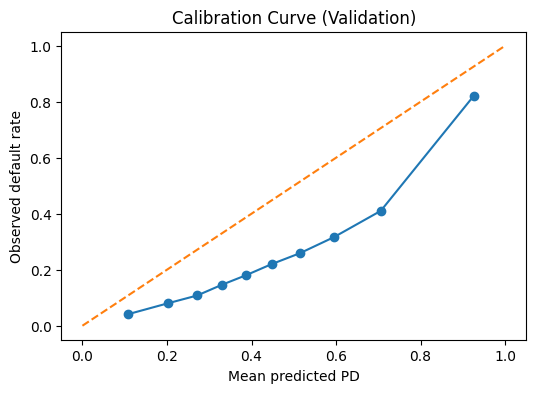

In [16]:
prob_true, prob_pred = calibration_curve(y_val, p_val, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Calibration Curve (Validation)")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.show()


# Feature importance

In [18]:
# Get feature names out of ColumnTransformer
pre = best_model.named_steps["preprocess"]
model = best_model.named_steps["model"]

# Get feature names directly from the fitted ColumnTransformer
feature_names = pre.get_feature_names_out()
coefs = model.coef_.ravel()

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df.sort_values("abs_coef", ascending=False).head(30)


,feature,coef,abs_coef
1055,cat__settlement_status_None,-1.034583,1.034583
999,cat__debt_settlement_flag_N,-1.034583,1.034583
1114,cat__settlement_date_None,-1.034583,1.034583
1050,cat__debt_settlement_flag_date_None,-1.034583,1.034583
1000,cat__debt_settlement_flag_Y,1.034386,1.034386
67,num__out_prncp,0.575424,0.575424
68,num__out_prncp_inv,0.575266,0.575266
1054,cat__settlement_status_COMPLETE,0.540174,0.540174
17,num__funded_amnt_inv,-0.438668,0.438668
923,cat__hardship_status_BROKEN,0.437292,0.437292
